Lazy-PRM-Extionsion and Collision Checks
============

by Eric Schubert and Philipp Meyer

## 1. Introduction

### Why collision checking is a deciding factor for planning time?

#### Complex Geometric Tests:
Collision checking requires calculating intersections between 3D objects (robot and environment). Computing exact positions and geometric overlaps involves computationally expensive operations.

#### Continuous Configuration Space:
Checking a trajectory in a continuous space requires discretizing the path. Finer resolutions guarantee safety but significantly increase the number of checks, creating a strict trade-off between safety and computational cost.

#### Optimization Lever:
Standard planners evaluate every generated node and edge, but only one path is ultimately executed. The vast majority of checks are therefore wasted on unused regions. Reducing this sheer volume of unnecessary checks is the primary method to decrease planning time.

### What is the idea behind Lazy PRM?

The core idea is to delay the computationally expensive collision checks as much as possible. Instead of validating the roadmap during construction, the algorithm only checks nodes and edges that are on a found path.

➜ The algorithm only checks edges that have a high probability of being part of the final solution, strictly avoiding collision checks in irrelevant areas of the $C$-space, which have a higher probability of being unnecessary.

➜ we try to reuse information by remembering nodes and queries that are collision free

### Investigated Lazy PRM variants

❌ not finished. What does he want to hear here?

We investigated LazyPRM with UniformSampler, BridgeSampler and CollidingEdgeSampler

### Criteria used for Evaluation

## 2. Analysis of existing implementations

| Implementation | Description |
|--------|-------------|
| _buildRoadMap | Predetermined number of nodes are placed at random positions. Connect each node to its *k* nearest neighbors. |
| _checkForCollisionAndUpdate | check if the node itself is colliding with an obstacle -> if yes remove<br>for every path between two nodes -> check if the line is colliding with an obstacle -> if yes remove the edge and store the removed edge. |
| Edge storation | collidingEdges = we store connections between nodes that collide with obstacles, so that we know they are not possible and we also don't try to add them again in the future<br>nonCollidingEdges = edges that are possible -> this is not implemented yet, but we probably want to store which edges we already have checked so that we can reuse this knowledge later on. |
| initialRoadmapSize | number of Nodes of the first roadmap|
|updateRoadmapSize | number of nodes to add if there is no connection from start to end|
|kNearest | number of nodes to connect to during setup|
|maxIterations | fail-safe limit that dictates how many times the algorithm is allowed to add new nodes and retry finding a path before giving up, preventing an infinite loop when no solution exists.|

### How does the Visualization in IPVISLazyPRM.py work?
draw obstacles and graph <br>
draw all connected components, emphasize the largest one<br>
draw collidingEdges in red<br>
nonCollidingEdges in yellow<br>
StartNode in Green, goal in Red<br>
Solution Path in green<br>


### What are the limits of the equally distributed node-enhancement phase?
❌ not finished

the points are sampled randomly -> so not necessary in the area where we would need them. But because they are random we are also not committing to a wrong region or stuff like that.

## 4. Comparison of LazyPRM Node Checking vs. Early Node Checking

❌ not finished

Also introduced AbstractGraphPRM which inherits from PRMBase.

how can we make qualified assessments about the performance (because the points are always just sampled randomly -> can do both good or bad) -> do we really have to run them for 50 times or something? Or is a theoretical investigation sufficient -> I think so because in a later exercise we should run them 30 times.

The name EarlyPRM probably has to be changed

|                | LazyPRM | EarlyPRM |
|:---------------|:--------|:---------|
| Good when      | - Sparse environment<br>- Few collisions | - Dense environment<br>- Many collisions |
| Bad when       | - we risk planning paths on nodes and edges that are invalid | - if there aren't many obstacles we are too cautious |


In dense environments EarlyPRM helps us with having to try many paths that work anyway, because we before identify that the nodes are invalid. But if there are few or no obstacles one could just go without the caution EarlyPRM provides.

In [1]:
from IPEarlyPRM import EarlyPRM
from IPLazyPRM import LazyPRM
from IPVISLazyPRM import customPRMVisualize, animatePRMVisualize
import matplotlib.pylab as plt
import IPTestSuite as ts
from IPNodeSampling import CollidingEdgeSampler, BridgeSampler

from IPPerfMonitor import IPPerfMonitor


Benchmark: Trap (Level 2)


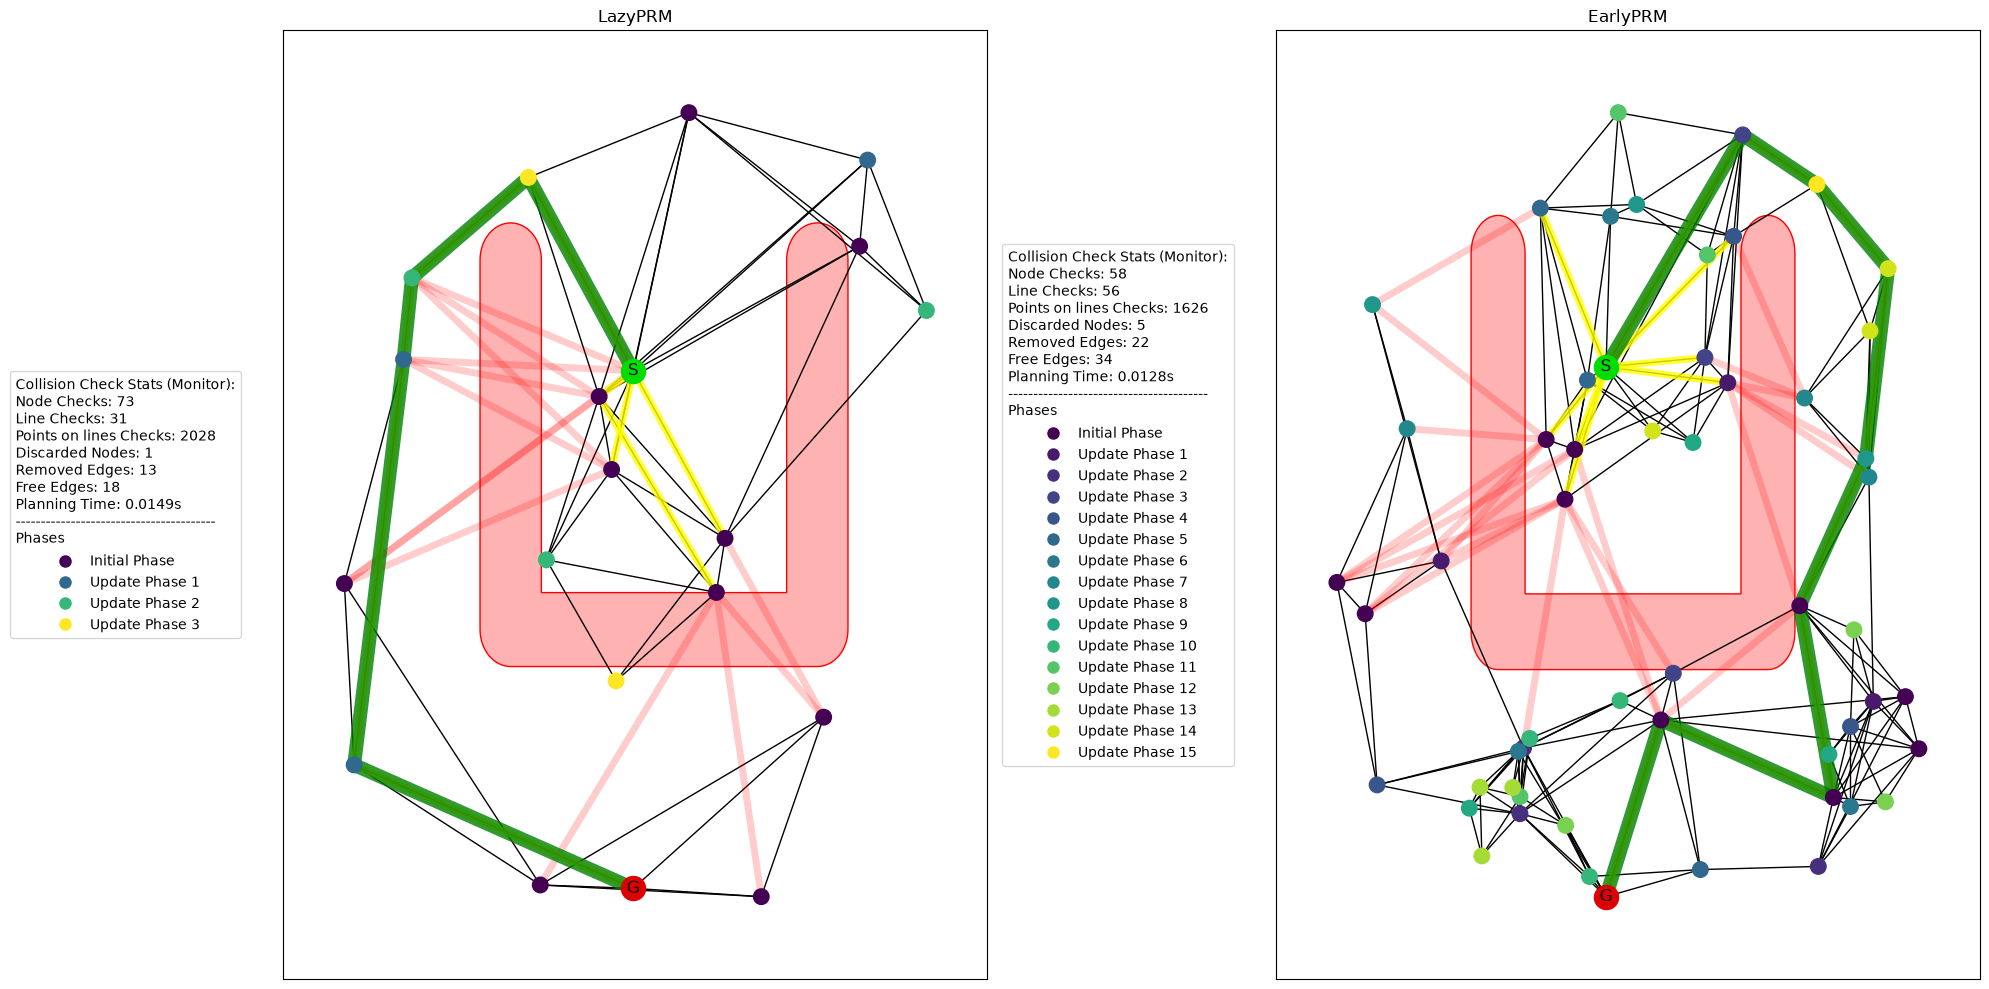

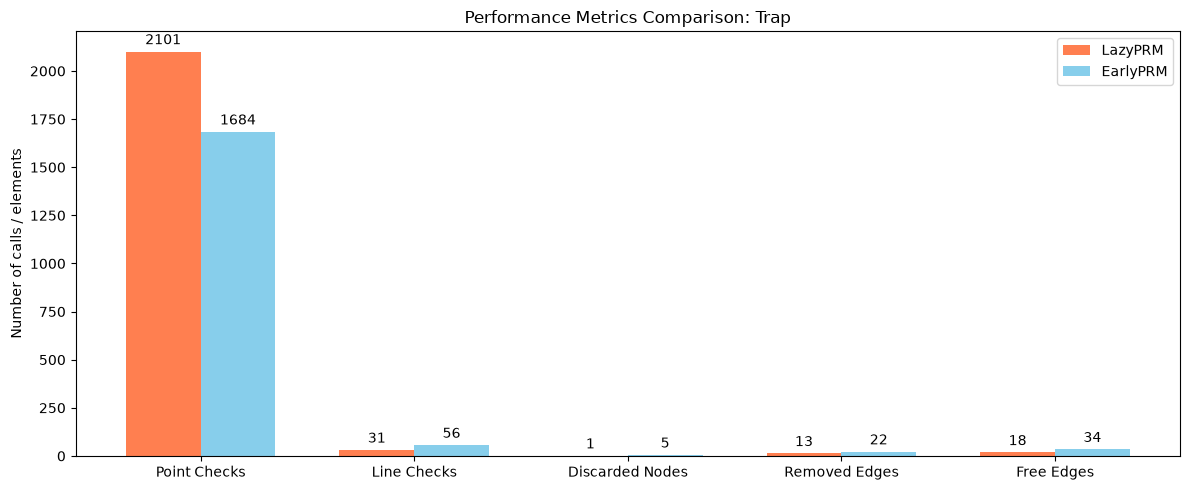


--- Interactive View: Trap ---


IntSlider(value=0, description='Timeline:', max=15)

Output()


--- Sampling History View: Trap ---


IntSlider(value=0, description='Enhance Call:', max=2)

Output()


Benchmark: Bottleneck (Level 2)


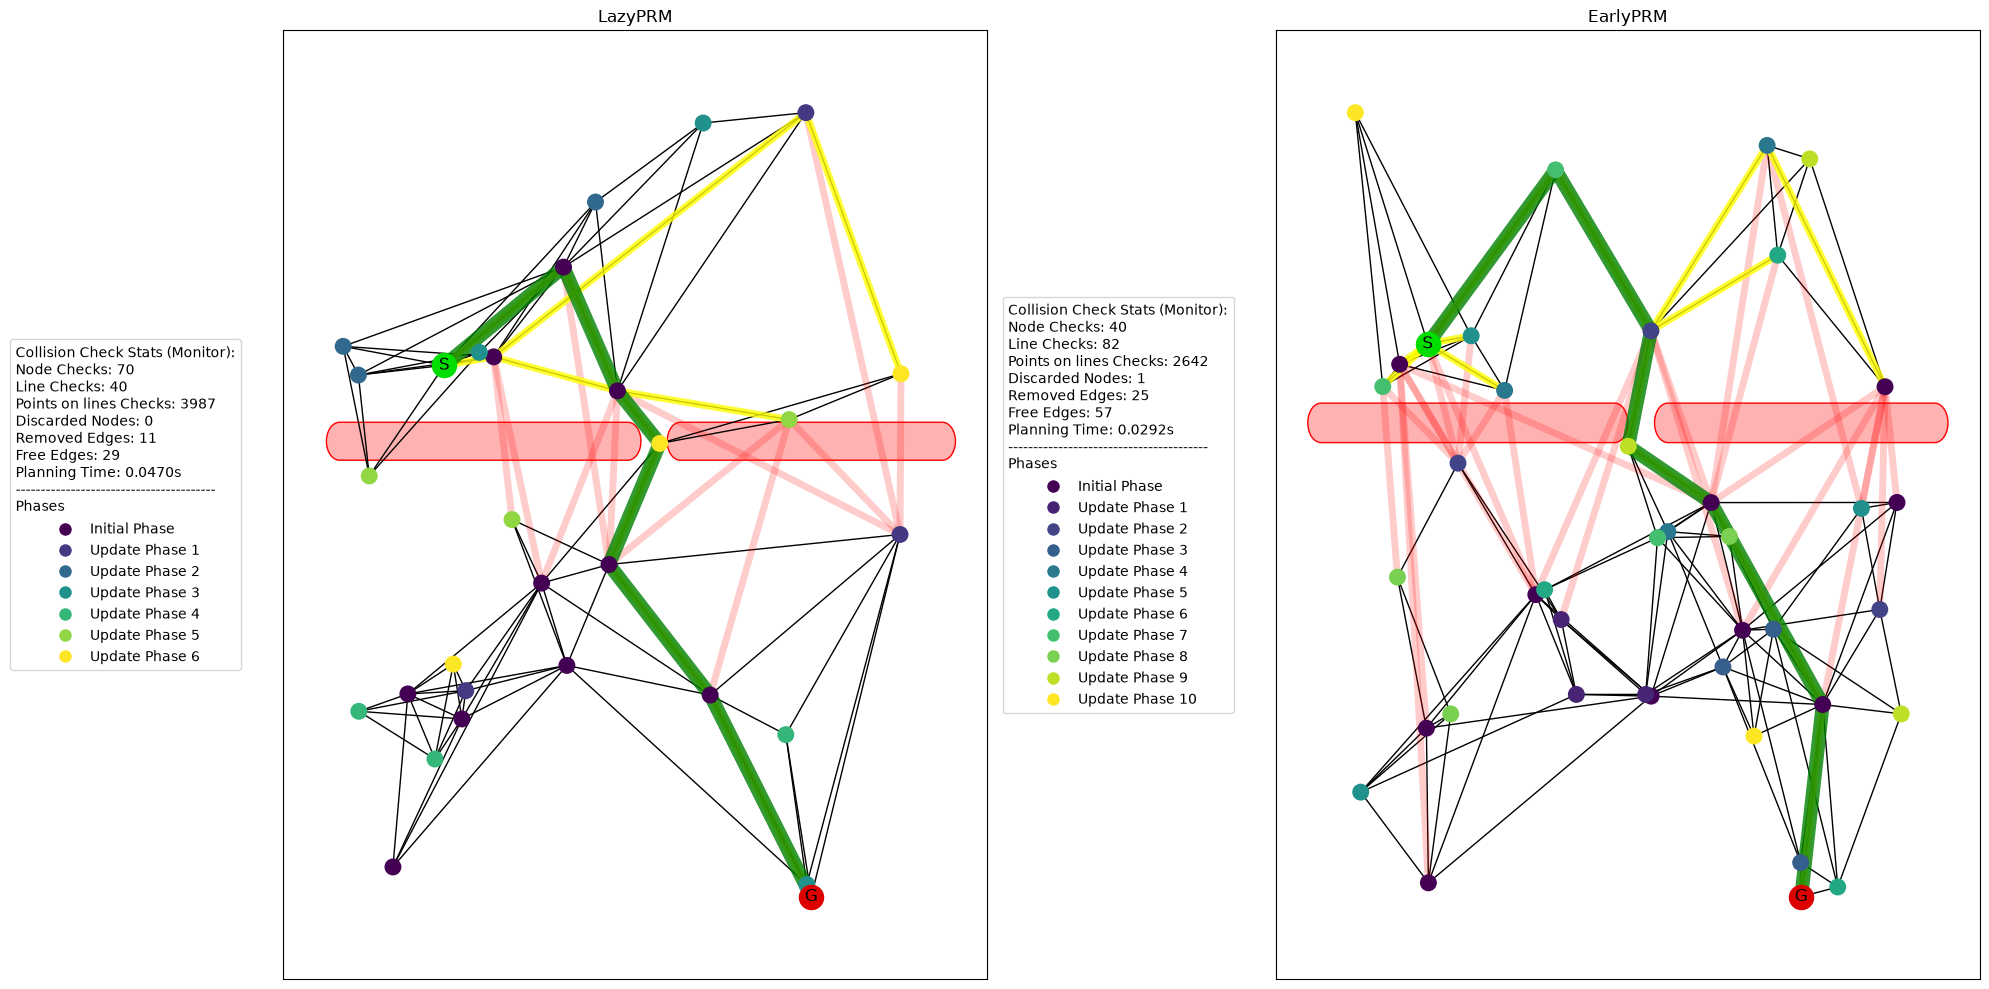

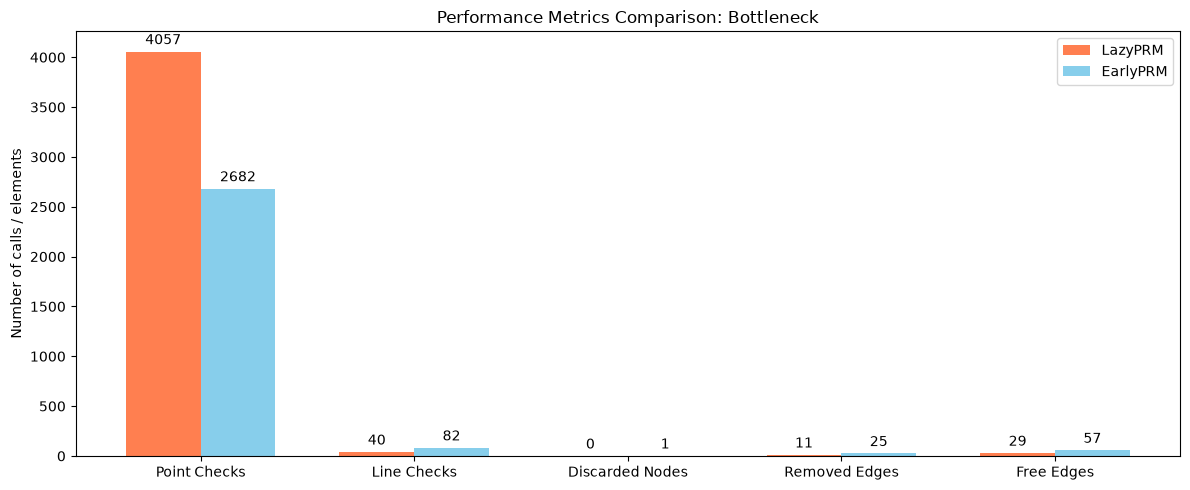


--- Interactive View: Bottleneck ---


IntSlider(value=0, description='Timeline:', max=10)

Output()


--- Sampling History View: Bottleneck ---


IntSlider(value=0, description='Enhance Call:', max=5)

Output()


Benchmark: Fat bottleneck (Level 2)


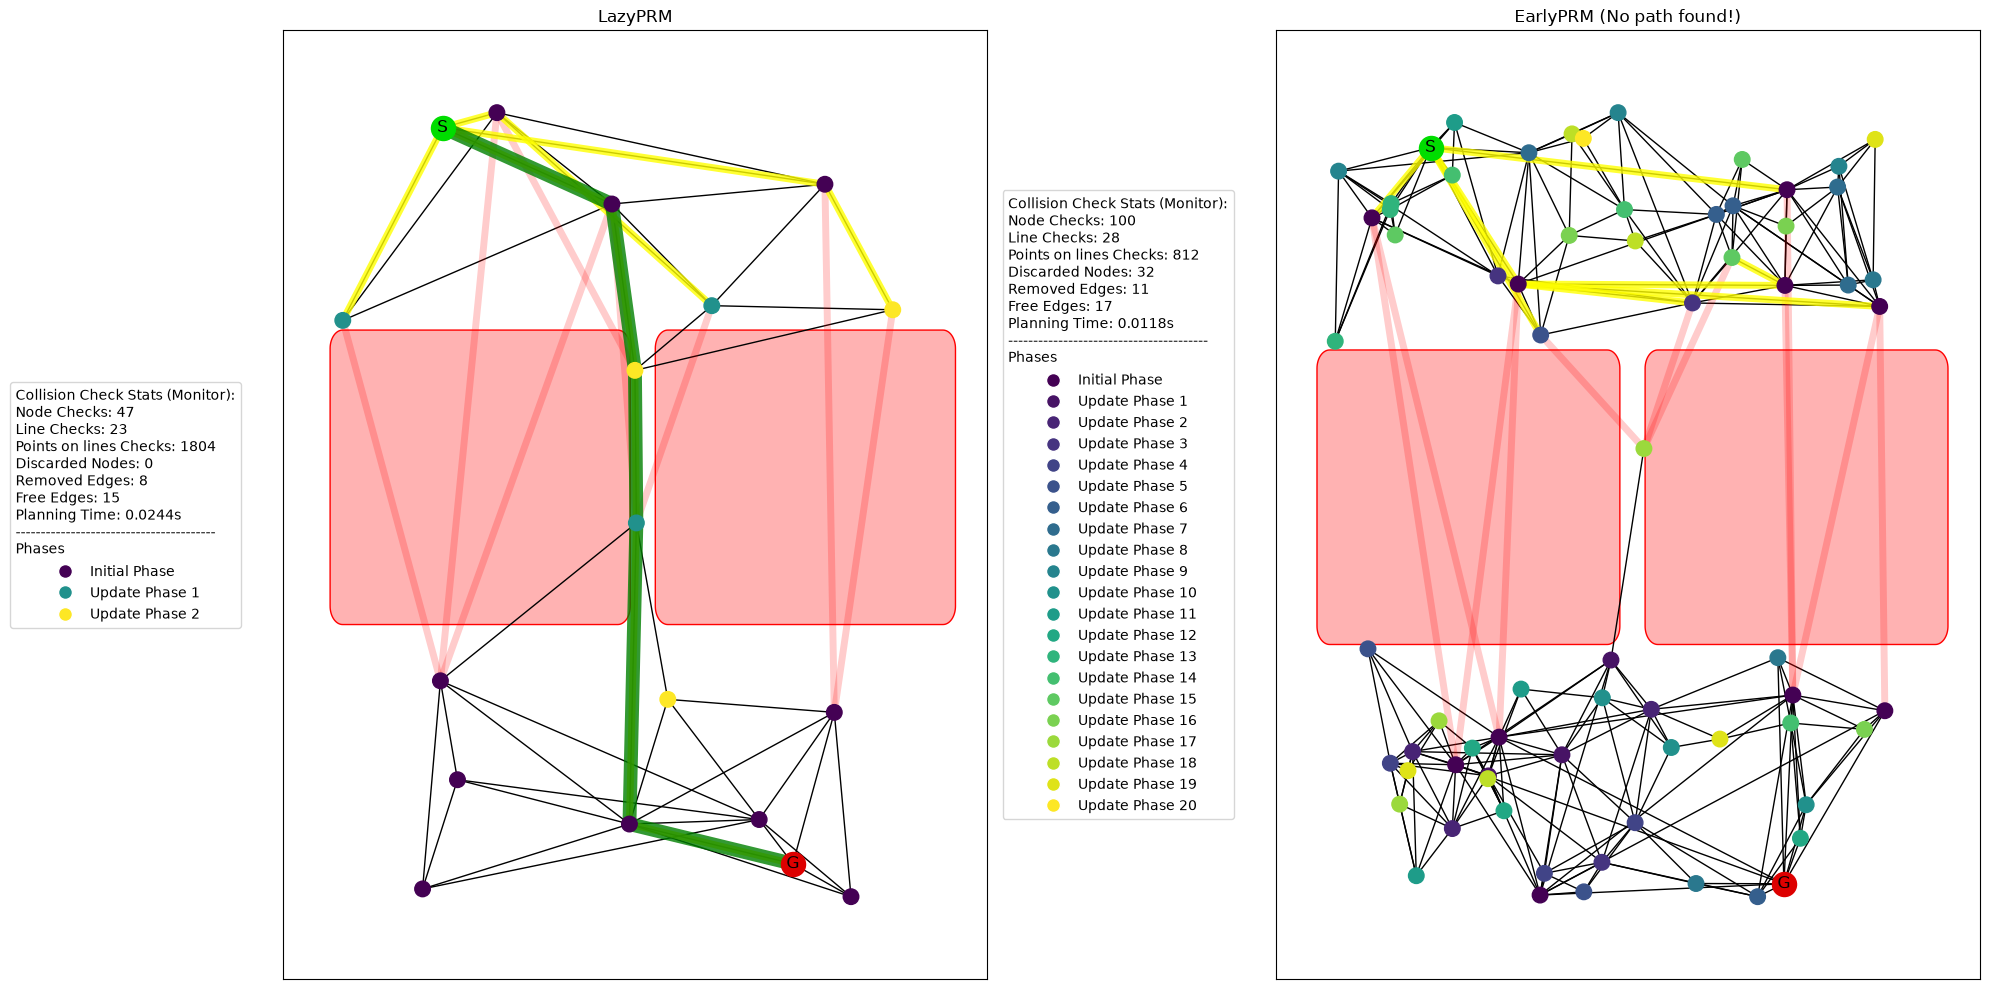

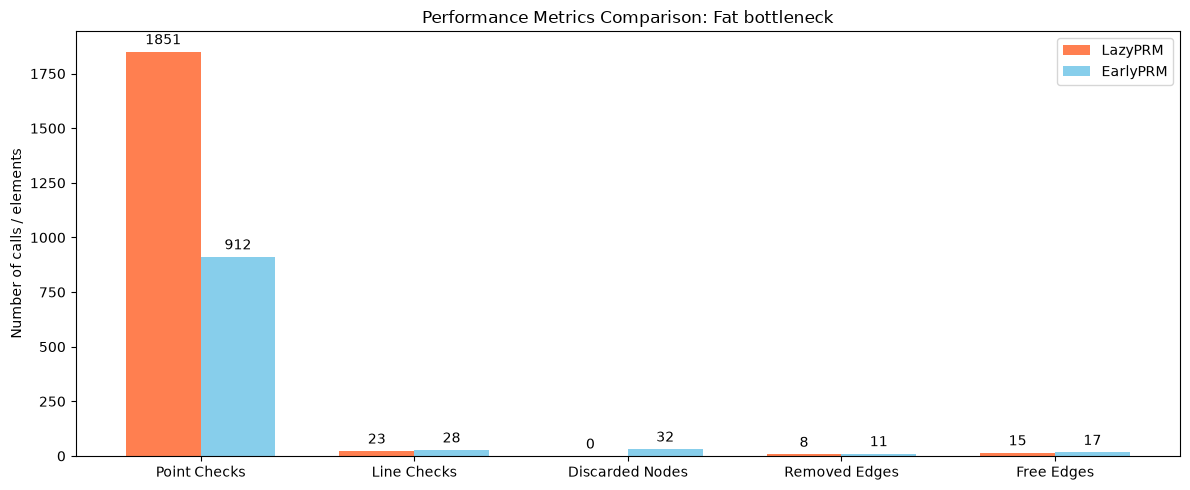


--- Interactive View: Fat bottleneck ---


IntSlider(value=0, description='Timeline:', max=20)

Output()


--- Sampling History View: Fat bottleneck ---


IntSlider(value=0, description='Enhance Call:', max=1)

Output()


Benchmark: MyField (Level 2)


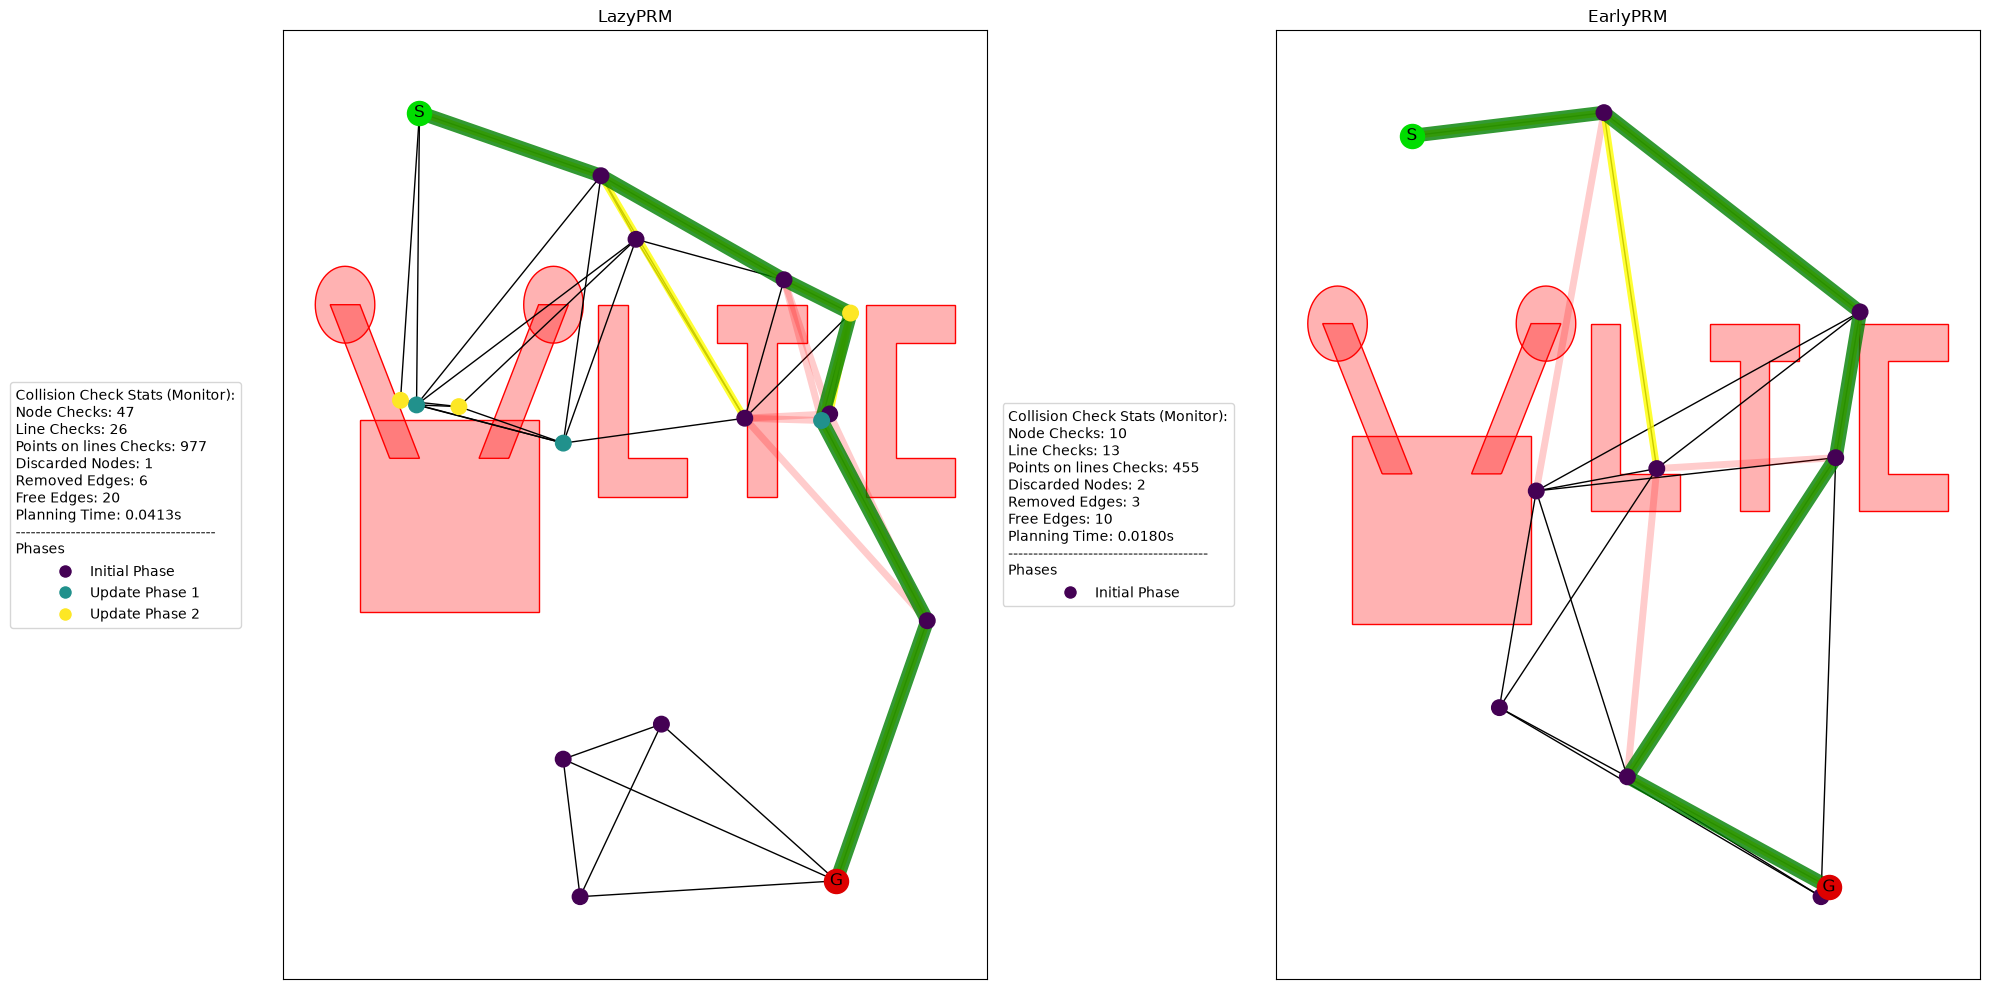

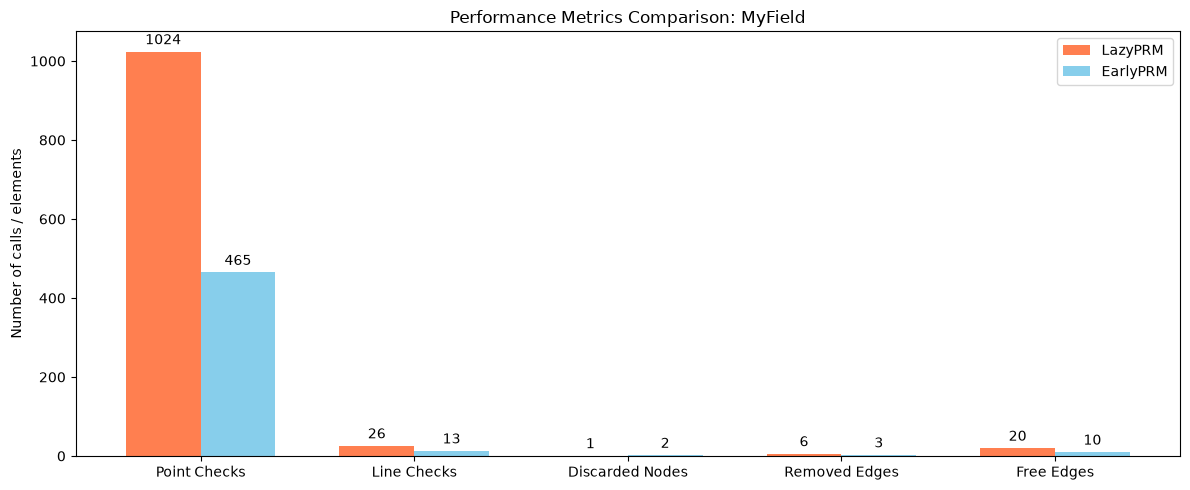


--- Interactive View: MyField ---


IntSlider(value=0, description='Timeline:', max=2)

Output()


--- Sampling History View: MyField ---


IntSlider(value=0, description='Enhance Call:', max=1)

Output()


Benchmark: Zigzag Traps (Level 2)


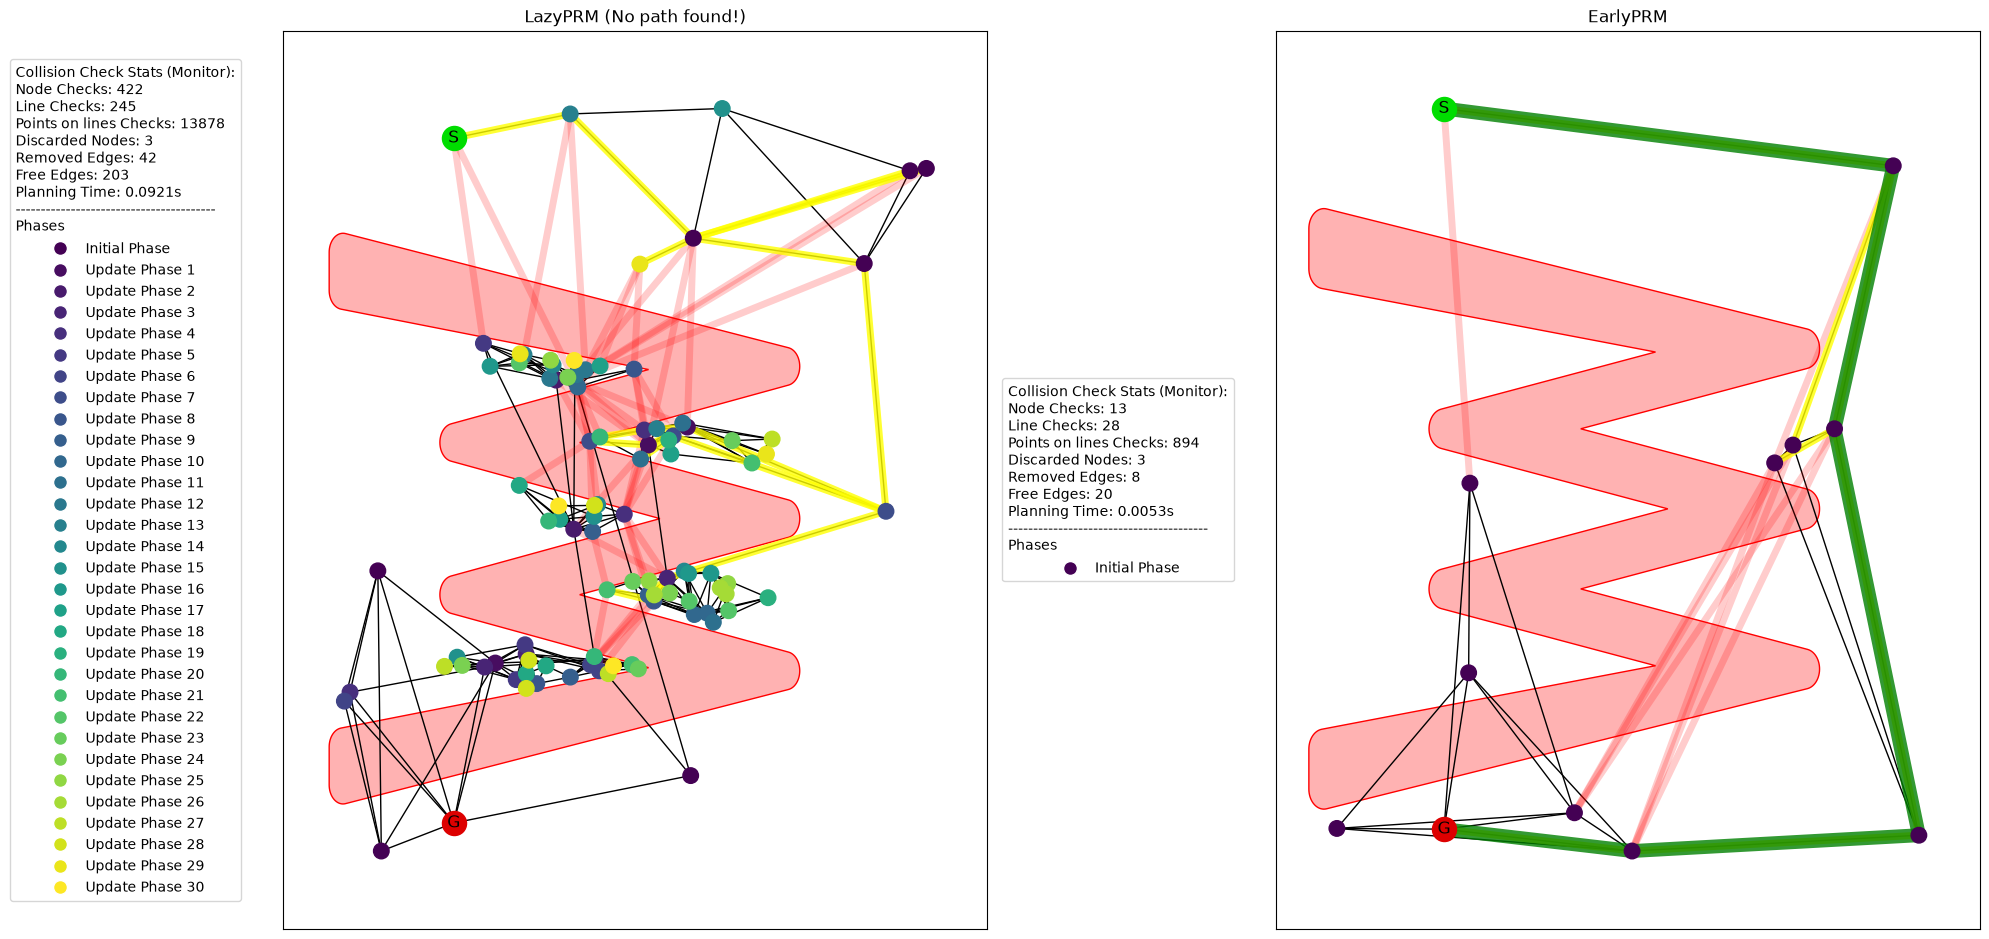

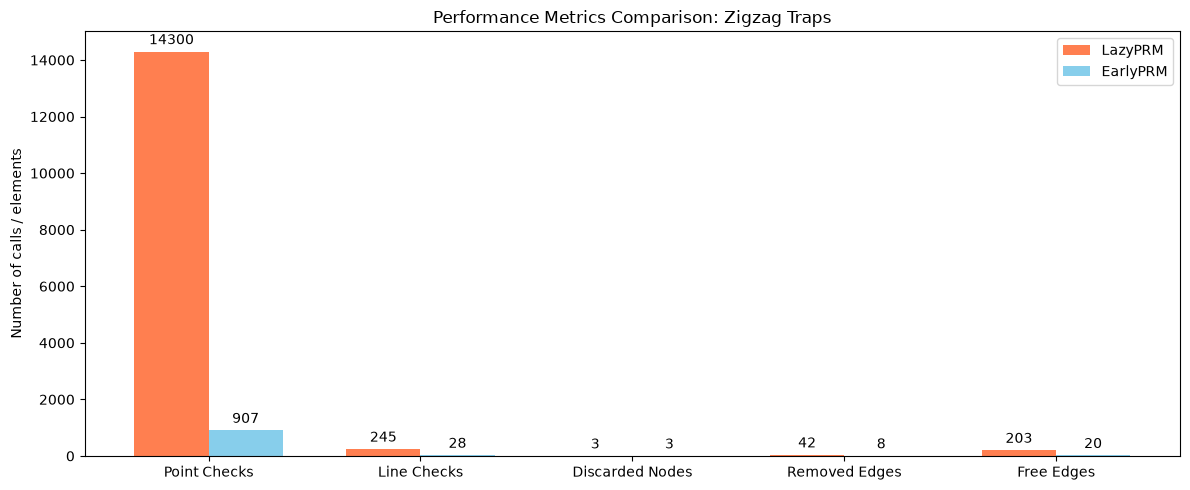


--- Interactive View: Zigzag Traps ---


IntSlider(value=0, description='Timeline:', max=30)

Output()


--- Sampling History View: Zigzag Traps ---


IntSlider(value=0, description='Enhance Call:', max=29)

Output()


Benchmark: Empty Field (Level 2)


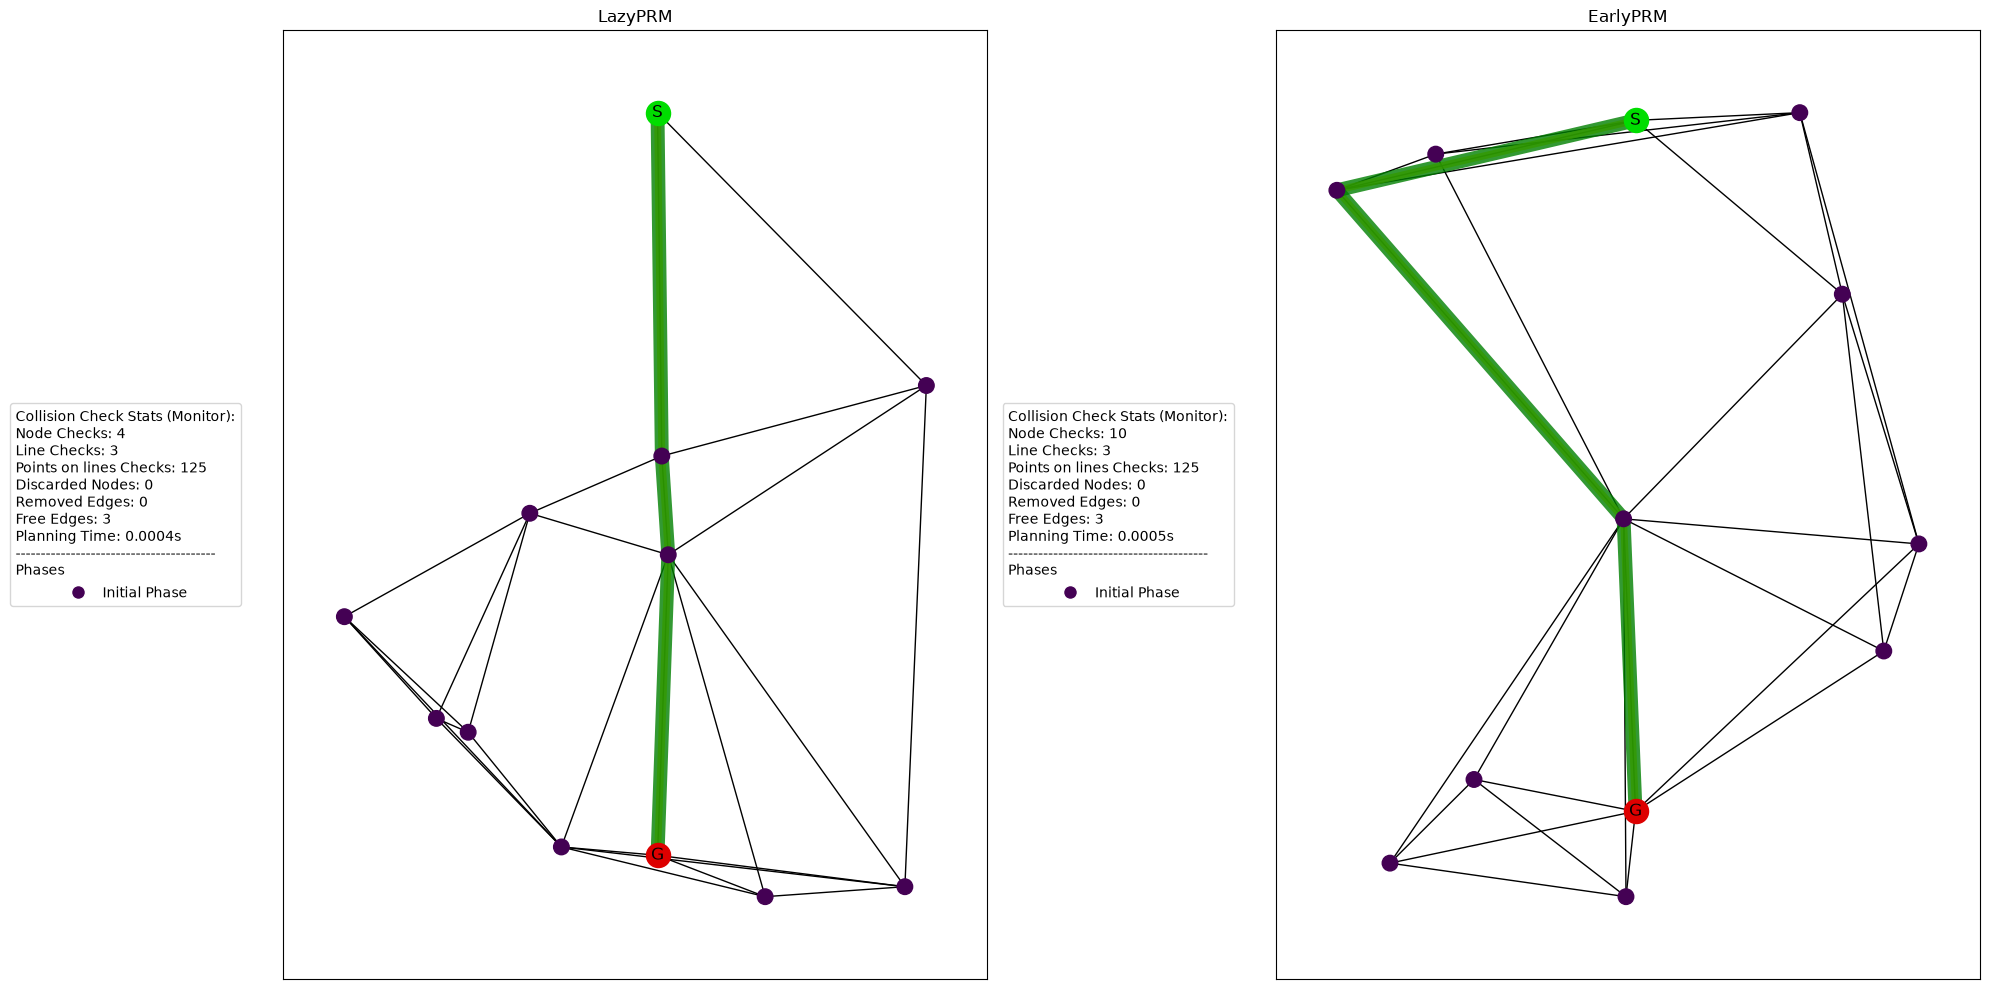

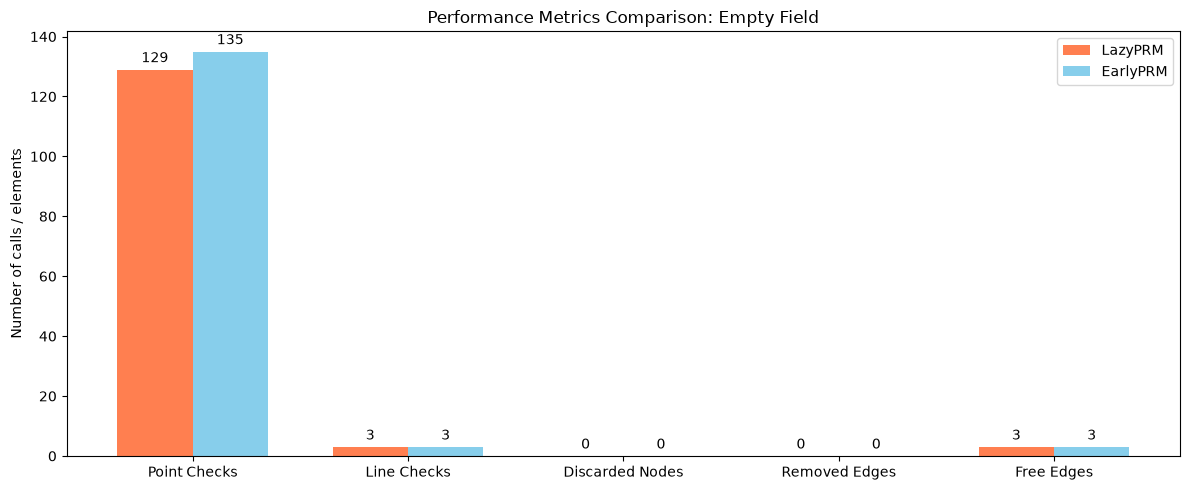


--- Interactive View: Empty Field ---


IntSlider(value=0, description='Timeline:', max=0)

Output()


--- No local sampling history recorded for Empty Field ---

Benchmark: Clutter Forest (Level 2)


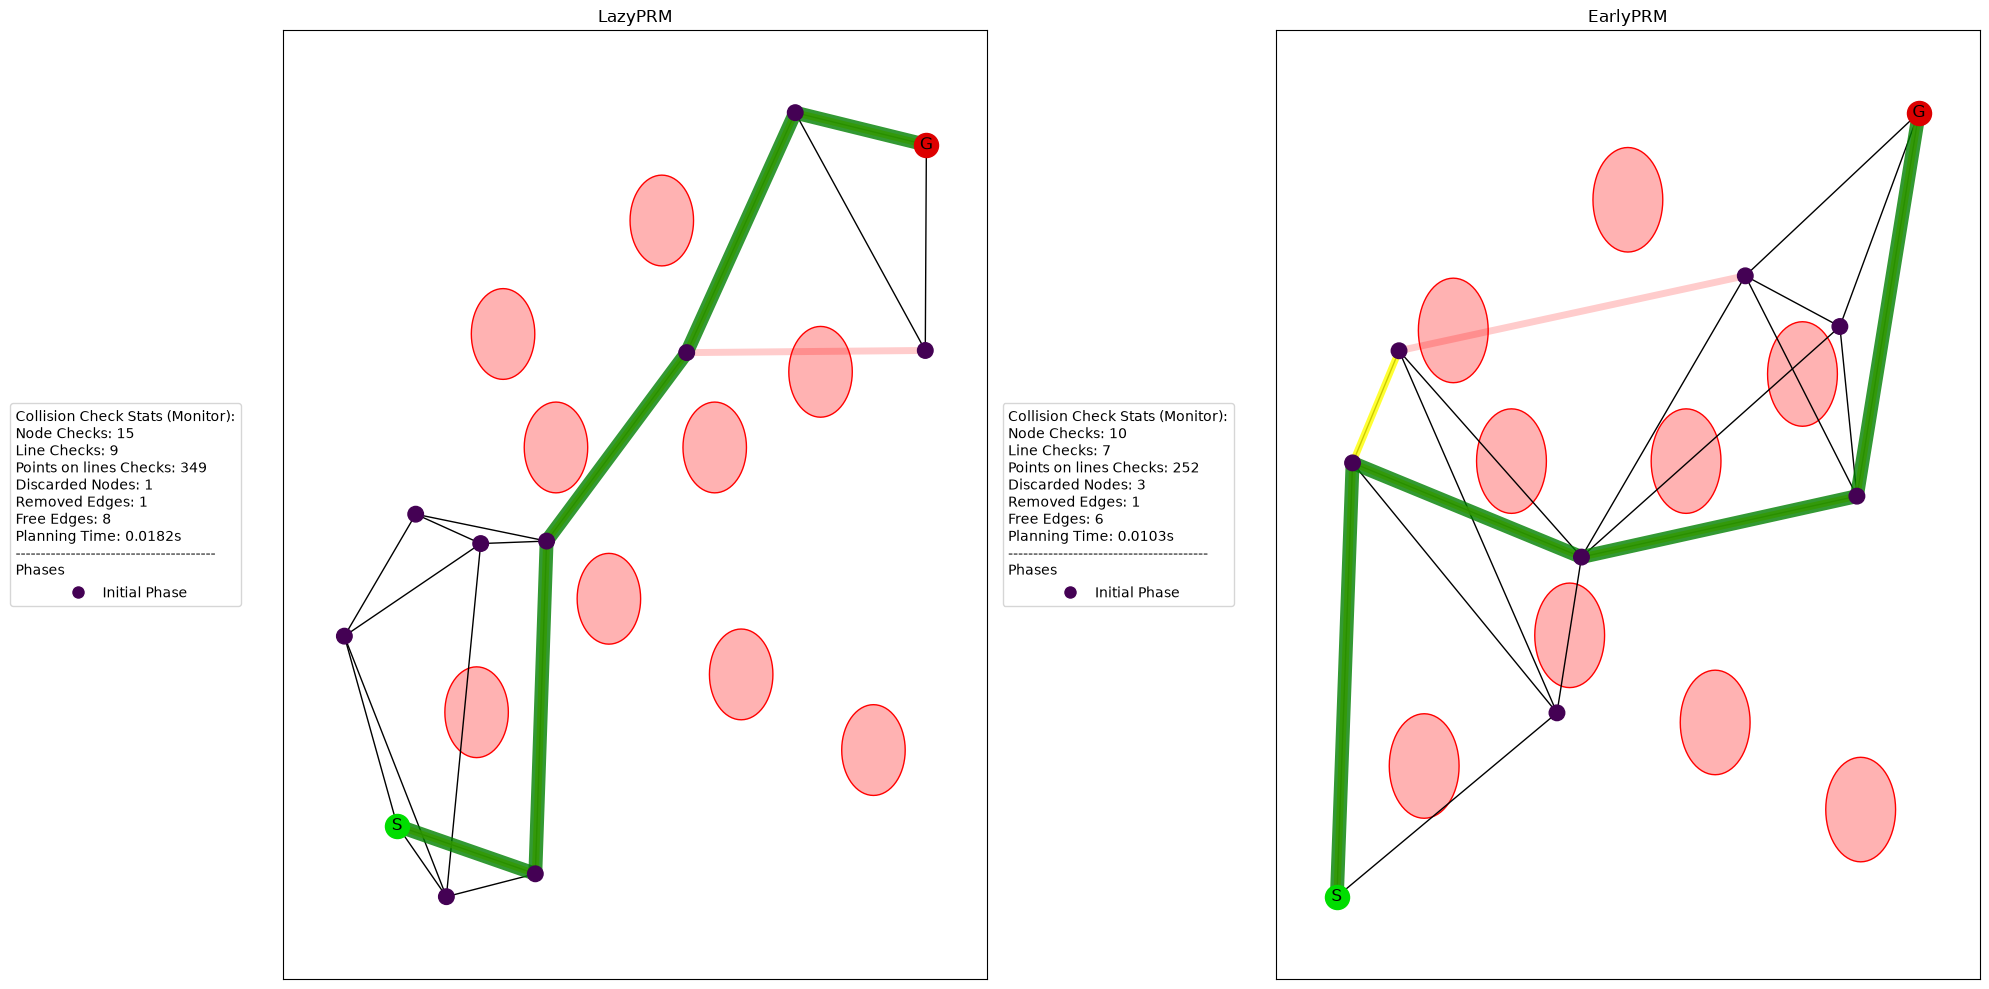

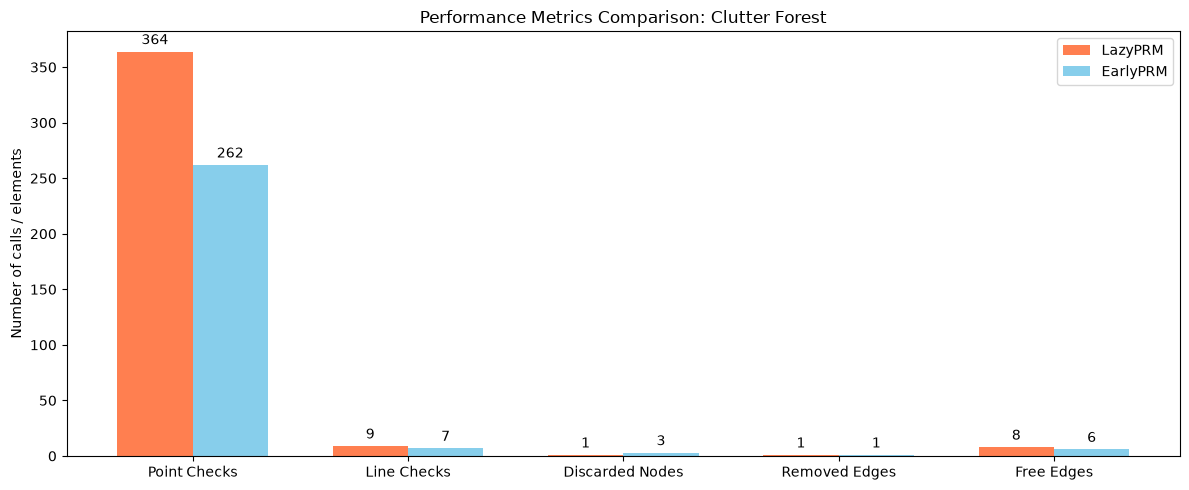


--- Interactive View: Clutter Forest ---


IntSlider(value=0, description='Timeline:', max=0)

Output()


--- No local sampling history recorded for Clutter Forest ---

Benchmark: Dual Path (Level 2)


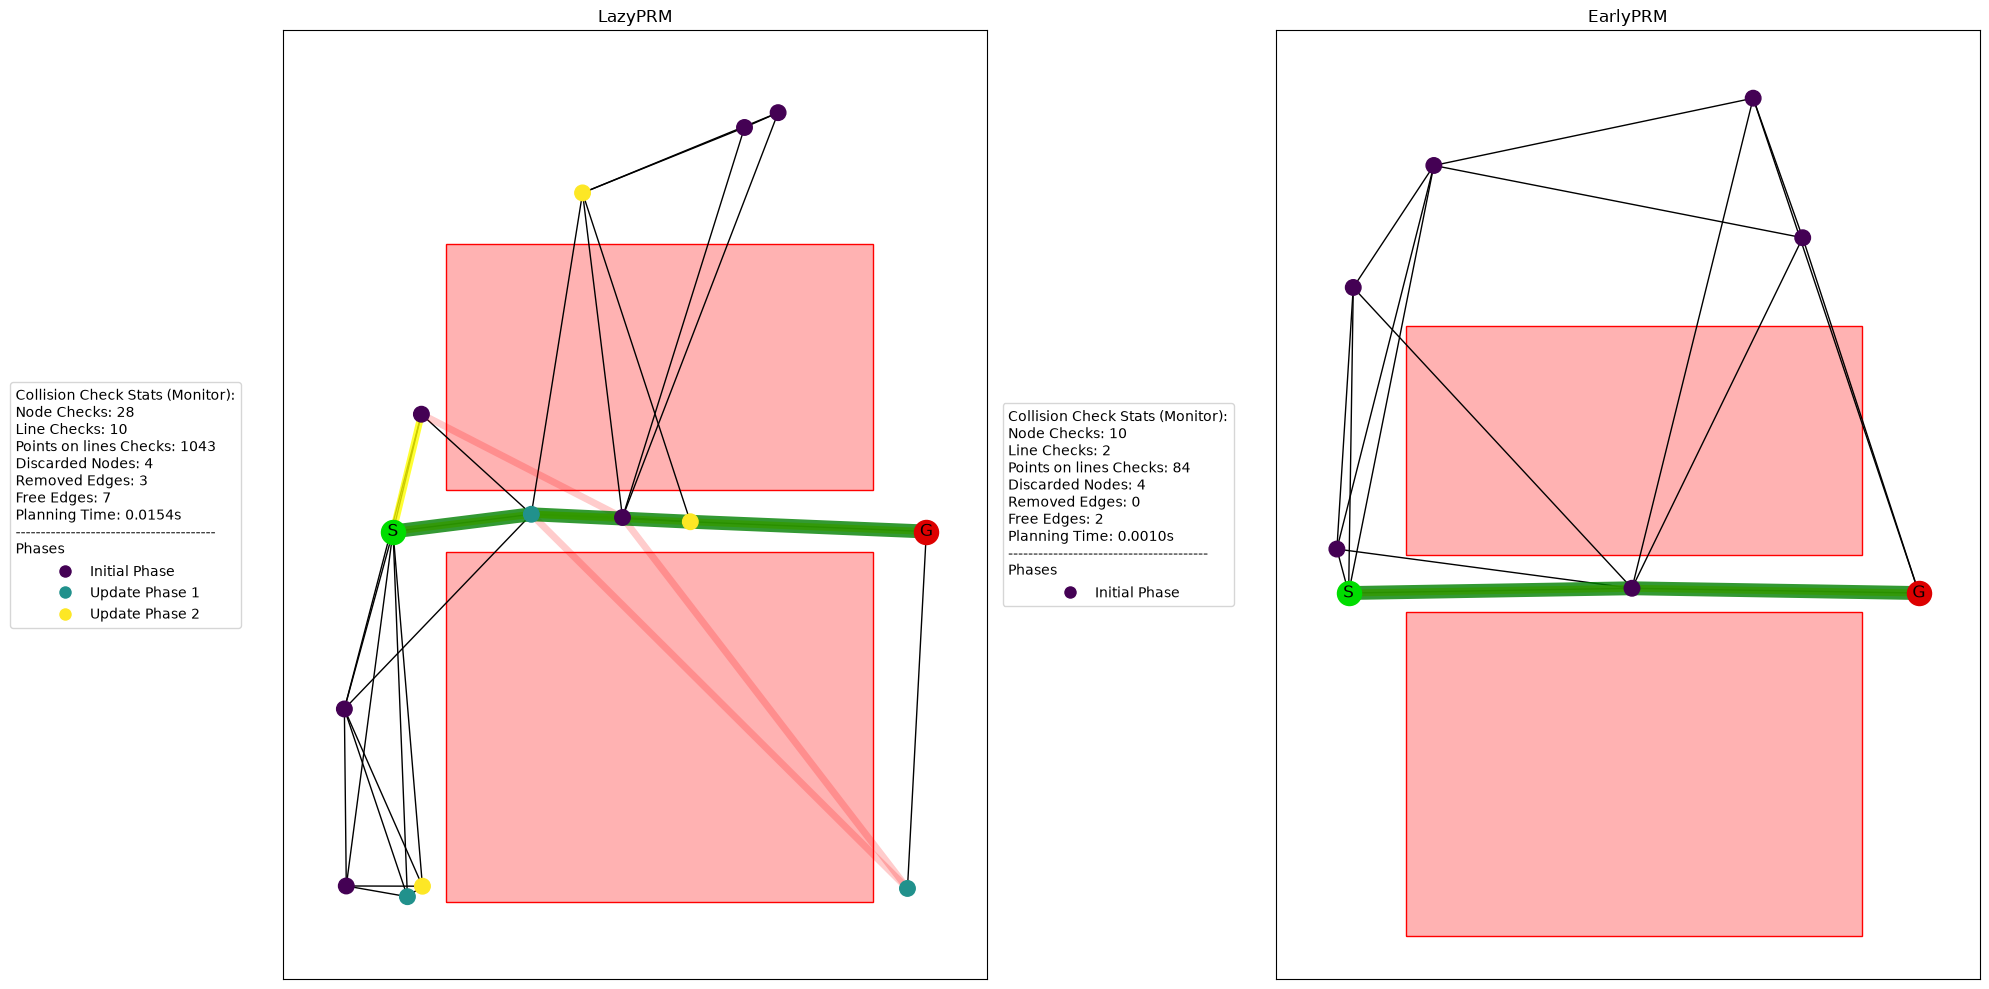

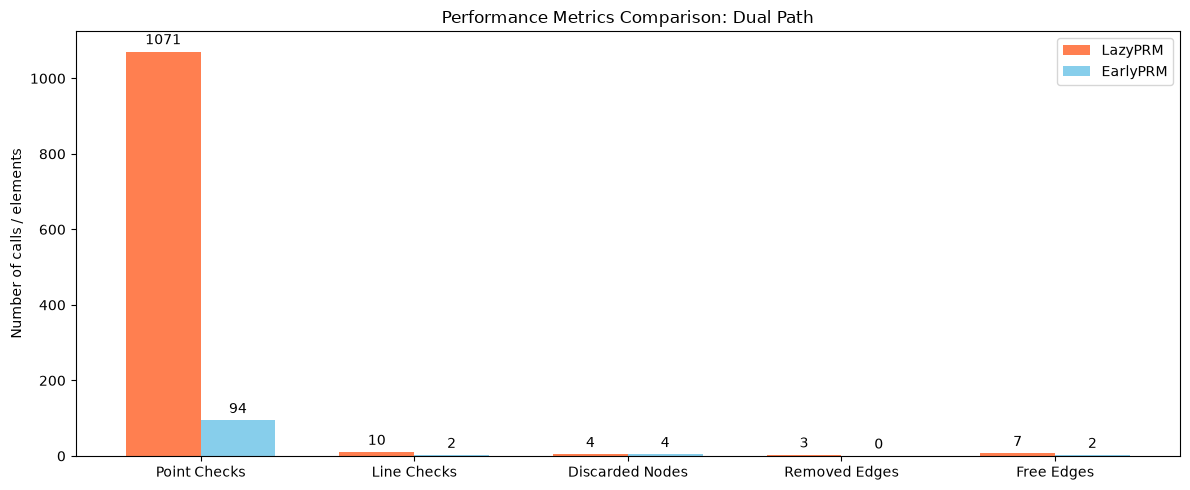


--- Interactive View: Dual Path ---


IntSlider(value=0, description='Timeline:', max=2)

Output()


--- Sampling History View: Dual Path ---


IntSlider(value=0, description='Enhance Call:', max=1)

Output()


Benchmark: Nested Trap (Level 2)


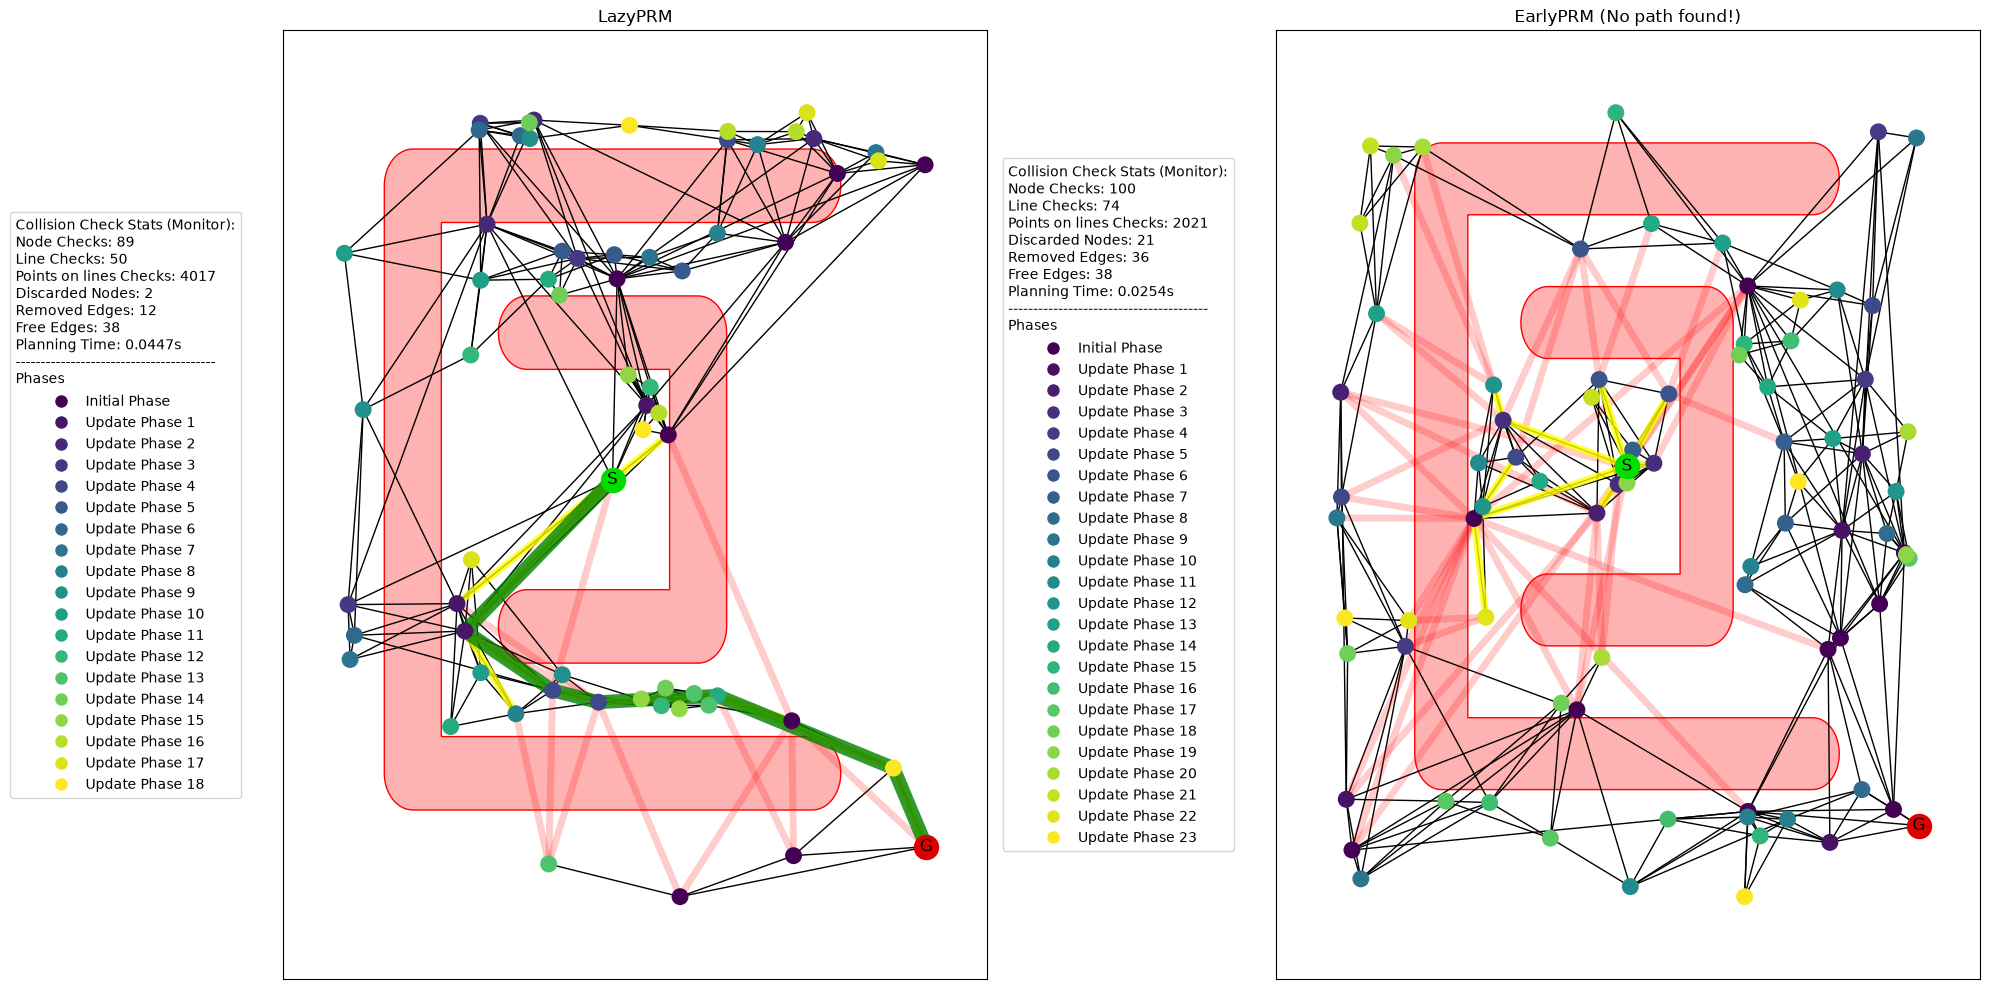

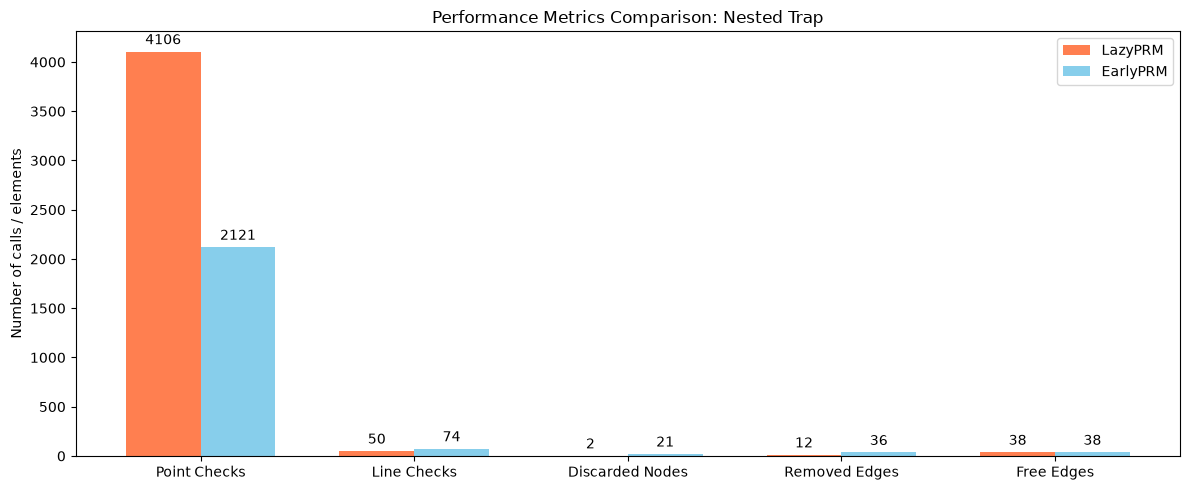


--- Interactive View: Nested Trap ---


IntSlider(value=0, description='Timeline:', max=23)

Output()


--- Sampling History View: Nested Trap ---


IntSlider(value=0, description='Enhance Call:', max=17)

Output()


Benchmark: Giant Square (Level 2)


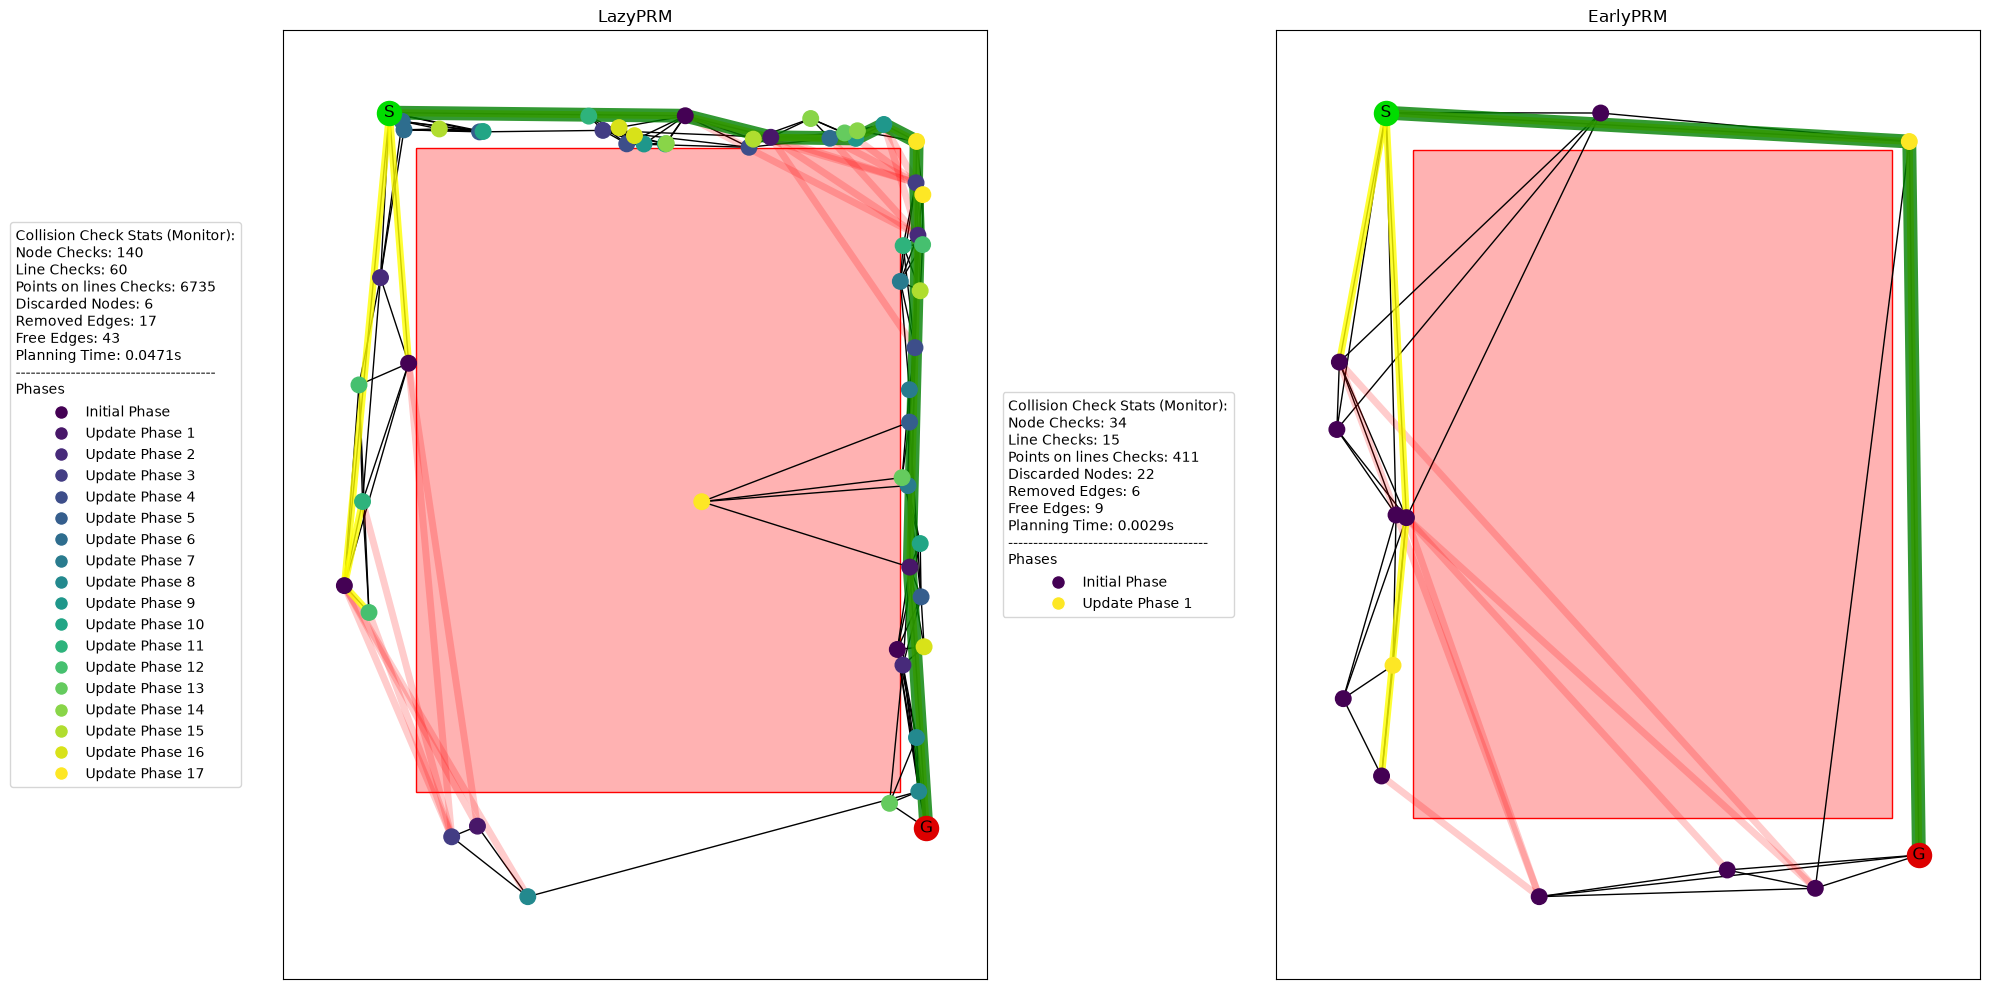

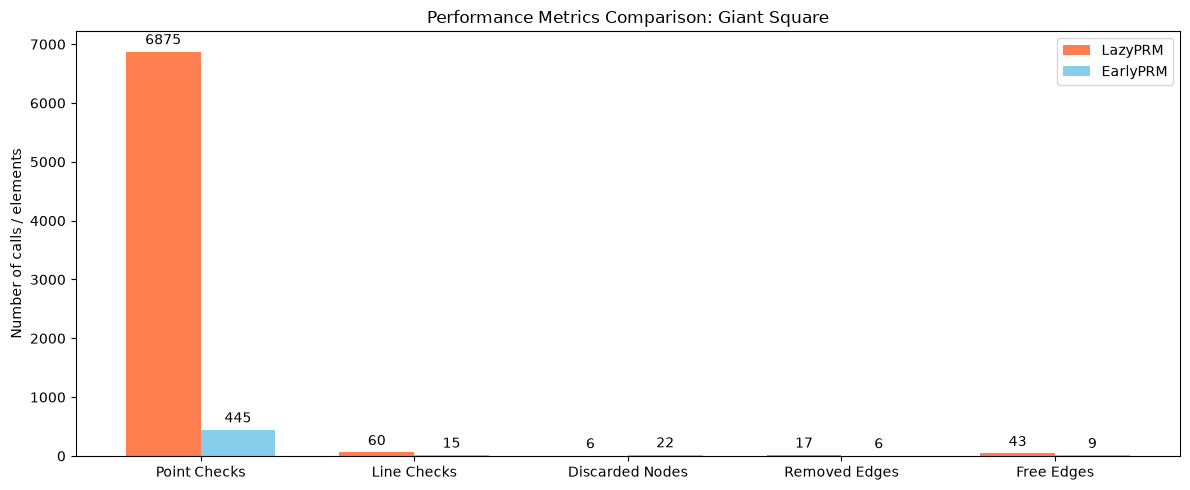


--- Interactive View: Giant Square ---


IntSlider(value=0, description='Timeline:', max=17)

Output()


--- Sampling History View: Giant Square ---


IntSlider(value=0, description='Enhance Call:', max=16)

Output()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from IPSamplerVisualizer import SamplerVisualizer


# Hilfsfunktion, um die maximale Phase für den Slider zu berechnen
def get_max_phase(planner, init_size, update_size):
    nodes = [n for n in planner.graph.nodes() if isinstance(n, int)]
    if not nodes:
        return 0
    max_node = max(nodes)
    if max_node < init_size:
        return 0
    return 1 + (max_node - init_size) // update_size

lazyConfig = dict()
lazyConfig["initialRoadmapSize"] = 10
lazyConfig["updateRoadmapSize"] = 3
lazyConfig["kNearest"] = 5
lazyConfig["maxIterations"] = 30

for benchmark in ts.benchList:
    print(f"\n{'='*60}\nBenchmark: {benchmark.name} (Level {benchmark.level})\n{'='*60}")

    # ---------------------------------------------------------
    # 1. STATIC VISUALIZATION
    # ---------------------------------------------------------
    fig_graphs = plt.figure(figsize=(20, 10))
    ax1 = fig_graphs.add_subplot(1, 2, 1)
    ax2 = fig_graphs.add_subplot(1, 2, 2)

    # Run LazyPRM
    IPPerfMonitor.clearData()
    collidingEdgeSampler = CollidingEdgeSampler()
    bridgeSampler = BridgeSampler()
    try:
        vis_lazy = LazyPRM(benchmark.collisionChecker, enhancer=bridgeSampler)
        solution_lazy = vis_lazy.planPath(
            benchmark.startList,
            benchmark.goalList,
            lazyConfig,
        )

        ax1.set_title("LazyPRM" + (" (No path found!)" if not solution_lazy else ""))
        plt.sca(ax1)
        # Wenn du deine Methode überschrieben hast, kannst du hier auch customPRMVisualize(..., max_phase=None) nutzen
        customPRMVisualize(vis_lazy, lazyConfig["initialRoadmapSize"], lazyConfig["updateRoadmapSize"], solution_lazy, ax=ax1, nodeSize=125)

        df_lazy = IPPerfMonitor.dataFrame()
        p_checks_lazy = len(df_lazy[df_lazy["name"] == "pointInCollision"]) if not df_lazy.empty else 0
        l_checks_lazy = len(df_lazy[df_lazy["name"] == "lineInCollision"]) if not df_lazy.empty else 0
        rem_nodes_lazy = len(vis_lazy.collidingNodes)
        rem_edges_lazy = len(vis_lazy.collidingEdges)
        free_edges_lazy = len(vis_lazy.nonCollidingEdges)

    except Exception as e:
        print("ERROR LazyPRM:", benchmark.name, e)
        plt.close(fig_graphs)
        continue

    # Run EarlyPRM
    IPPerfMonitor.clearData()
    try:
        vis_early = EarlyPRM(benchmark.collisionChecker)
        solution_early = vis_early.planPath(
            benchmark.startList,
            benchmark.goalList,
            lazyConfig,
        )

        ax2.set_title("EarlyPRM" + (" (No path found!)" if not solution_early else ""))
        plt.sca(ax2)
        customPRMVisualize(vis_early, lazyConfig["initialRoadmapSize"], lazyConfig["updateRoadmapSize"], solution_early, ax=ax2, nodeSize=125)

        df_early = IPPerfMonitor.dataFrame()
        p_checks_early = len(df_early[df_early["name"] == "pointInCollision"]) if not df_early.empty else 0
        l_checks_early = len(df_early[df_early["name"] == "lineInCollision"]) if not df_early.empty else 0
        rem_nodes_early = len(vis_early.collidingNodes)
        rem_edges_early = len(vis_early.collidingEdges)
        free_edges_early = len(vis_early.nonCollidingEdges)

    except Exception as e:
        print("ERROR EarlyPRM:", benchmark.name, e)
        plt.close(fig_graphs)
        continue

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 2. STATISTICS (Bar Chart)
    # ---------------------------------------------------------
    labels = ["Point Checks", "Line Checks", "Discarded Nodes", "Removed Edges", "Free Edges"]
    lazy_stats = [p_checks_lazy, l_checks_lazy, rem_nodes_lazy, rem_edges_lazy, free_edges_lazy]
    early_stats = [p_checks_early, l_checks_early, rem_nodes_early, rem_edges_early, free_edges_early]

    x = np.arange(len(labels))
    width = 0.35

    fig_stats, ax_stats = plt.subplots(figsize=(12, 5))
    ax_stats.bar(x - width / 2, lazy_stats, width, label="LazyPRM", color="coral")
    ax_stats.bar(x + width / 2, early_stats, width, label="EarlyPRM", color="skyblue")

    ax_stats.set_ylabel("Number of calls / elements")
    ax_stats.set_title(f"Performance Metrics Comparison: {benchmark.name}")
    ax_stats.set_xticks(x)
    ax_stats.set_xticklabels(labels)
    ax_stats.legend()

    offset = max(lazy_stats + early_stats) * 0.01

    for i, value in enumerate(lazy_stats):
        ax_stats.text(i - width / 2, value + offset, str(value), ha="center", va="bottom", fontsize=10)
    for i, value in enumerate(early_stats):
        ax_stats.text(i + width / 2, value + offset, str(value), ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()


    # ---------------------------------------------------------
    # 3. INTERACTIVE ANIMATION (Slider)
    # ---------------------------------------------------------

    # Compute the maximum phase the slider can reach
    max_phase_lazy = get_max_phase(vis_lazy, lazyConfig["initialRoadmapSize"], lazyConfig["updateRoadmapSize"])
    max_phase_early = get_max_phase(vis_early, lazyConfig["initialRoadmapSize"], lazyConfig["updateRoadmapSize"])
    max_possible_phase = max(max_phase_lazy, max_phase_early)

    # 1. Factory function (captures the current loop iteration state)
    def create_plot_function(current_vis_lazy, current_vis_early, current_sol_lazy, current_sol_early, b_name, conf):

        # 2. Actual plotting function
        def plot_animation_step(current_phase):
            fig_anim, (ax1_anim, ax2_anim) = plt.subplots(1, 2, figsize=(20, 10))

            # Draw LazyPRM frame (using the captured variables)
            ax1_anim.set_title(f"LazyPRM ({b_name}) - Phase {current_phase}")
            animatePRMVisualize(
                current_vis_lazy,
                conf["initialRoadmapSize"],
                conf["updateRoadmapSize"],
                current_sol_lazy,
                ax=ax1_anim,
                nodeSize=125,
                max_phase=current_phase,
            )

            # Draw EarlyPRM frame
            ax2_anim.set_title(f"EarlyPRM ({b_name}) - Phase {current_phase}")
            animatePRMVisualize(
                current_vis_early,
                conf["initialRoadmapSize"],
                conf["updateRoadmapSize"],
                current_sol_early,
                ax=ax2_anim,
                nodeSize=125,
                max_phase=current_phase,
            )

            plt.tight_layout()
            plt.show()

        return plot_animation_step

    # Create the plotting function for the current benchmark
    bound_plot_function = create_plot_function(
        vis_lazy,
        vis_early,
        solution_lazy,
        solution_early,
        benchmark.name,
        lazyConfig,
    )

    # Create the slider
    slider = widgets.IntSlider(
        min=0,
        max=max_possible_phase,
        step=1,
        value=0,
        description="Timeline:",
    )

    # Link the slider to the captured plotting function
    out = widgets.interactive_output(bound_plot_function, {"current_phase": slider})

    # Display the slider and animation in the notebook
    print(f"\n--- Interactive View: {benchmark.name} ---")
    display(slider, out)



    # ---------------------------------------------------------
    # 4. SAMPLING VISUALIZATION (Interactive Slider)
    # ---------------------------------------------------------
    used_enhancer = vis_lazy.enhancer if hasattr(vis_lazy, 'enhancer') else pathLocalEnhancer

    if hasattr(used_enhancer, 'history') and len(used_enhancer.history) > 0:
        samp_visualizer = SamplerVisualizer()
        
        samp_visualizer.show_interactive_slider(
            b_name=benchmark.name,
            history_log=used_enhancer.history,
            prm_graph=vis_lazy.graph,
            conf=lazyConfig,
            all_free_edges=vis_lazy.nonCollidingEdges if hasattr(vis_lazy, 'nonCollidingEdges') else [],
            checker=benchmark.collisionChecker,
            enhancer_name=used_enhancer.__class__.__name__
        )
    else:
        print(f"\n--- No local sampling history recorded for {benchmark.name} ---")

## 5. Node Enhancement Strategies:


### CollidingEdgeSampler:
**Idea**: Sample near where the previous solution failed

**Process**: Whenever the PRM tries to connect two nodes and the edge fails because it intersects an obstacle, this sampler intervenes.
It takes the blocked line segment (between pos_a and pos_b).
It interpolates a random point directly on this line using a random scalar t ∈[0,1].
It applies Gaussian noise (with standard deviation sigma) to this interpolated point, shifting it slightly in a random direction.


**Rationale**:
We want to leverage the intent of the planner.<br>
When an edge collides, it provides valuable information: the algorithm wants to travel along this specific trajectory, usually because it is the most direct or promising route between two regions in the graph.
While uniform sampling completely discards this intent and blindly guesses elsewhere, this sampler capitalizes on it. By adding noise directly to the blocked segment, it actively searches for local alternatives that maintain the planner's desired direction. We are essentially generating slight detours to offer similar alternatives to the path the planner originally intended to take, allowing it to bypass the blocking obstacle without abandoning the route entirely

### BridgeSampler
**Idea**: Prioritize critical regions over open space. Since narrow passages and obstacle vicinity are difficult to sample with uniform methods, this strategy deliberately increases the sampling density in these critical areas.

**Process**: Sampler intentionally looks for collisions to find bottlenecks.
It generates a random point p1 and checks if it lies inside an obstacle.
If it does, it takes a Gaussian step to generate a second point p2.
If p2 is also inside an obstacle, it calculates the exact midpoint pm between p1 and p2.
If this midpoint pm is collision-free (in free space), it is accepted as a new valid node in the graph.
We adapted the point collision checking, so that we are able to distinguish if a point is in an obstacle or outside the allowed area.

**Rationale**: We want to solve the classic Narrow Passage Problem in motion planning.
Statistically, standard uniform sampling is very unlikely to drop a point inside a tiny, narrow corridor. The Bridge Sampler solves this by counter-intuitively searching for collisions instead of free space. Since the "walls" bounding a narrow passage are usually massive and much easier to hit than the free space itself, the algorithm searches for two obstacle points that are close to each other. By taking the midpoint between these two opposing walls, we effectively build a "bridge" over the gap. This approach guarantees that we are actively dropping critical waypoints directly into the bottlenecks that the planner needs to traverse.


### Visualization and Traceability Extension
**Implementation**: In both sampler classes, we integrated a history data structure to log the generation process. For the Bridge Sampler specifically, we additionally record the spatial anchors (p1 ,p2) used to evaluate the narrow passage.

**Rationale**:
We wanted to access the contextual metadata of how and why a specific node was generated. By explicitly logging the structural origin of each node, such as the specific collision_segment utilized for local repair or the obstacle boundaries serving as anchors, we preserve the exact provenance of the sampled data. <br>
This extension is crucial for our ability to fully comprehend and evaluate the underlying sampling dynamics. It allows us to retrace the algorithm's generative mechanism and represent it visually. Instead of treating the probabilistic generation as an opaque "black box," we can systematically verify the logic behind each node placement.

## 6. Visualization of Enhancement Strategies

### Standard PRM Visualization
Before diving into the complex behavior of our custom sampling heuristics, we needed a way to understand the general, macro-level progression of the Probabilistic Roadmap. For our standard visualizations, we implemented two core functions to analyze the overall graph generation:

1. Static Phase Profiling (customPRMVisualize)
This function provides a comprehensive snapshot of the final generated roadmap. Its primary role is to color-code the nodes based on their generation phase. By mapping the integer IDs of the nodes to their respective update cycles, we create a visual gradient. This allows us to instantly differentiate between the nodes generated during the initial uniform sampling phase and those added during later update iterations. Additionally, this view integrates with our IPPerfMonitor to attach performance metrics directly to the plot.

2. General PRM Progression Animation (animatePRMVisualize)
To observe how the PRM algorithm behaves over time, we developed this animation tool. It serves as an interactive timeline for the general graph-building process. By filtering nodes and edges based on the phase in which they were generated, we can scrub through the timeline to watch the roadmap grow step-by-step. It provides a broad overview of when specific areas of the workspace were explored and when edges were successfully connected or discarded.



### SamplerVisualizer
While the standard visualizations provide a general overview of PRM progression, the following components are specifically designed to analyze the behavior and effects of the node enhancement strategies. The SamplerVisualizer therefore provides a more detailed view of the individual enhancement steps and their generated nodes.



### Layer-by-Layer Rendering
The plot_sampling method constructs a single frame of the algorithm's state. To ensure that complex, dense graphs remain readable, we utilize a strict layering system, acting like a stack of transparent overlays:

| Layer | Role | Explanation |
|:---------------|:--------|:---------|
| 1 | The Environment | We render the obstacles (red) and the collision free edges (yellow). This shows the verified collision-free roadmap established up to the current point in time. |
| 2 | Historical Context | To maintain context without visual clutter, data from previous sampling steps is rendered with high transparency (alpha=0.4 to 0.5). Past collision edges appear as pale salmon, and past sampled nodes as light steel blue. |
| 3 | Current Focus | Intent Repair: If the CollidingEdgeSampler is active, the blocked edge is drawn as a bold red line, highlighting the planner's failed trajectory.<br>Narrow Passage Bridging: If the BridgeSampler is active, we draw a dashed magenta line between the two obstacle anchors (p1 ,p2), visually proving the identification of a bottleneck. |
| 4 | The Result | The newly generated nodes are plotted on the topmost layer in opaque blue. This ensures the immediate output of the current heuristic step is never hidden behind obstacles or historical data. |

The visualizer also features dynamic legend construction (ax.get_legend_handles_labels()), which intelligently adapts to the current state (e.g., only showing the "Bridge Anchors" legend item if the bridge heuristic was actually utilized in the current frame). We also enforce spatial accuracy (ax.set_aspect('equal')) to ensure distances and Gaussian noise distributions are not visually distorted.

Examplary illustrations:
| CollidingEdgeSampler | BridgeSampler | 
|:---------------|:--------|
| 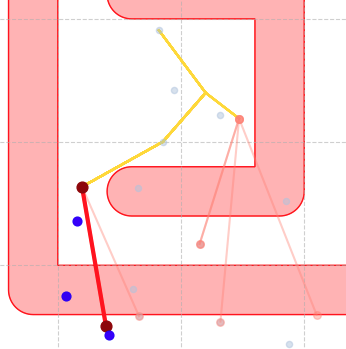 | 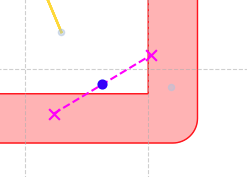 | 



### Animation
Motion planning is a highly dynamic process. Analyzing a static image of a final roadmap makes it nearly impossible to understand the sequence of the planner's spatial exploration. To solve this, we implemented the show_interactive_slider method using ipywidgets.
This method transforms our static plots into an interactive, scrubbable timeline.

The most critical mechanism in this interactive view is the temporal filtering of the graph edges:
When we scrub the slider to an earlier state (e.g., Call 2), the visualizer dynamically filters out any roadmap edges and nodes that were added in later iterations (e.g., Call 3 or 4). This guarantees that we do not accidentally "see the future." The visualization strictly represents the exact state of knowledge the planner had at that specific moment in time.

The interactive slider allows us to systematically step through the algorithm's decisions, making it significantly easier to identify structural weaknesses in a specific environment or to demonstrate why a targeted heuristic successfully solved a narrow passage where uniform sampling failed.

## 7. Validation on simple Examples:


### LazyPRM outperforms

| Image | Explanation |
|:------|:------------|
| 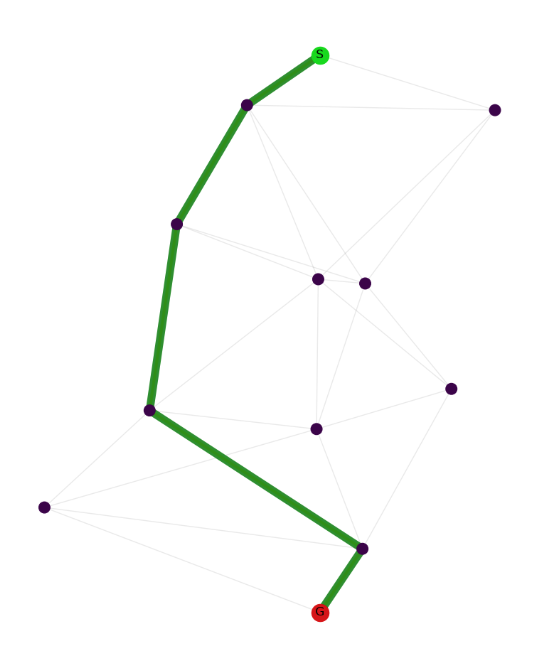 | **Weakness of EarlyPRM**<br>In this case there will never be any collision. However, EarlyPRM unconditionally evaluates every single sampled node and potential edge for collisions during the initial graph construction phase. This exhaustive upfront checking creates massive and entirely unnecessary computational overhead, which scales poorly as the initial roadmap size increases.<br><br>**Superiority of LazyPRM**<br>LazyPRM operates on the optimistic assumption that the configuration space is free. It first constructs a candidate path through the unverified graph and strictly limits its collision checks to the nodes and edges belonging to that specific trajectory. In an empty environment, this deferred validation ensures that computational effort is kept to the absolute mathematical minimum required to verify the final path.|


### EarlyPRM outperforms

| Image | Explanation |
|:------|:------------|
| 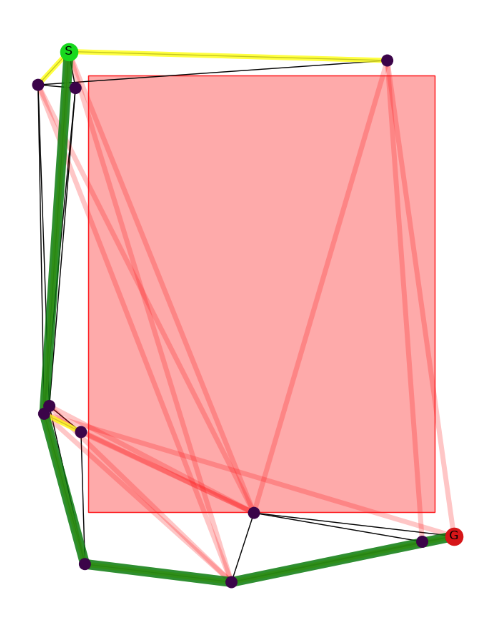 | **Weakness of LazyPRM**<br>In this environment, uniform sampling will inevitably place a significant portion of nodes inside colliding space. Because LazyPRM defers collision checking, it blindly constructs edges between these invalid nodes and actively searches for paths through them. When validation eventually occurs, these paths collapse. As a result, the invalid nodes and edges must be discarded, meaning a vast amount of computational effort, spent on graph building and searching, is completely wasted without generating any persistent, reusable knowledge for the roadmap.<br><br>**Superiority of EarlyPRM**<br>EarlyPRM strictly validates nodes and edges for collisions before integrating them into the roadmap. By immediately discarding invalid configurations, the algorithm ensures that the graph search only evaluates physically feasible, collision-free topologies. This completely eliminates the computational overhead of routing temporary paths through obstacles, guaranteeing that every connected edge contributes directly to a persistent, reliable, and reusable roadmap.|


### Targeted Node Enhancement outperforms

| Image | Explanation |
|:------|:------------|
| 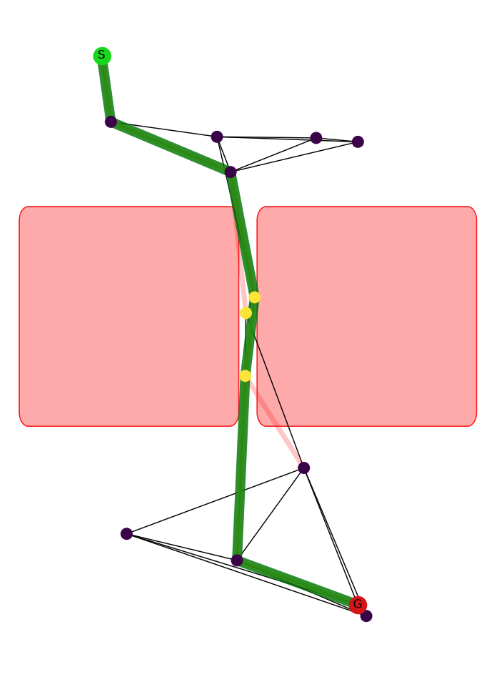 | **Weakness of Uniform Sampling**<br>Critical nodes are in the passage, while the rest of the environment is not particularly challenging. Uniform sampling has a very low probability of generating nodes in this specific area. We would need to get "lucky" to traverse that passage. This risks wasting time and resources on nodes and edges that do not contribute to navigating through the passage.<br><br>**Superiority of Bridge Sampling**<br>We actively seek out the obstacles to use them as guides. This helps us with sampling in critical areas. In this case by forcing the nodes into the passage.|